<a href="https://colab.research.google.com/github/535amar/DAS7000_Data-Analytics-Visualisation_S1_25/blob/main/Stu_Week_7_Workshop_student_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Case Study: MarketPulse Electronics - Interactive Data-Driven Sales Insights

MarketPulse Electronics - a rapidly expanding mid-sized electronics retailer - operates across New York, San Francisco, Boston, Los Angeles, and Seattle.

The company has completed a full year of digital sales tracking across multiple product categories - including phones, accessories, computers, and consumer electronics.

Now, the management wants to explore sales patterns interactively to answer complex questions about seasonality, pricing, customer behavior, and regional trends.

As a Data Analyst Consultant, you have been tasked to design an interactive analytics using Plotly Express and Plotly Graph Objects, that enables management to make data-driven decisions.

Dataset Overview

Dataset Used: Sales-Analysis-Dataset

Files: 12 monthly CSV files (January to December)

You need to answer for following business questions (Interactive Focus)

1. Seasonal Revenue Behavior

How do total monthly revenues fluctuate throughout the year?
Can we identify key peaks for example- holiday months and dips interactively?

Hint:

Derive a Month column from Order Date.

Create a dynamic line plot with tooltips and a range slider (go.Scatter).

Highlight months with sudden revenue surges.

2.  City-Wise Sales Distribution

Which U.S. cities bring in the highest total revenue, and how does the sales share differ by region?

Hint:

Extract City from Purchase Address.

Use a Plotly pie chart or choropleth map for interactive exploration.

Hover over each city to view total revenue and average order value.

3. Product Category Comparison

Which products or product types perform best across the year?
Can we compare unit sales and total revenue side-by-side?

Hint:

Use a double bar chart that compare Quantity Ordered vs Total Sales.

Allow users to hover to see revenue-per-item.

4. Hourly Purchase Patterns

During what times of day do customers make the most purchases?
Are late-night or morning sales more common?

Hint:

Extract the Hour from Order Date.

Use an interactive area or histogram plot (px.area or px.histogram).

Enable zooming to see micro trends (e.g., lunchtime spikes).

5. Revenue Distribution per Order

Visualize how transaction revenues vary across the dataset. Are most orders small or do we have a few large, high-value orders?

Hint:

Create a bubble scatter plot (px.scatter) with:

X-axis → Price Each

Y-axis → Quantity Ordered

Bubble size → Total Revenue

Hover to show product names and revenue.


Hints for Students

Combine 12 CSV files using:

all_data = pd.concat([pd.read_csv(f"Sales_{month}.csv") for month in months])


Convert Order Date to datetime:

all_data['Order Date'] = pd.to_datetime(all_data['Order Date'], errors='coerce')


Derive helper columns:

all_data['Month'] = all_data['Order Date'].dt.month
all_data['Hour'] = all_data['Order Date'].dt.hour
all_data['Sales'] = all_data['Quantity Ordered'] * all_data['Price Each']


Extract city names:

all_data['City'] = all_data['Purchase Address'].apply(lambda x: x.split(',')[1])


Use Plotly Express for quick interactivity:

import plotly.express as px


Add range sliders and hover info for richer visualised diagrams.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#plt.style.use('seaborn-darkgrid')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd '/content/drive/MyDrive/Colab/'

/content/drive/MyDrive/Colab


In [ ]:
import os

path = 'Week7'   # Folder where the 12 monthly files are stored
files = [file for file in os.listdir(path) if file.endswith('.csv')]

all_data = pd.DataFrame()
for file in files:
    df = pd.read_csv(os.path.join(path, file))
    all_data = pd.concat([all_data, df])

all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101"
1,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001"
2,236672,iPhone,1,700.0,08/06/19 14:40,"149 7th St, Portland, OR 97035"
3,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001"
4,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001"


In [ ]:
all_data.shape

(186850, 6)

In [ ]:
all_data.dropna(inplace=True)
all_data = all_data[~all_data['Order Date'].str.contains('Order Date')]

In [ ]:
all_data['Order Date'] = pd.to_datetime(all_data['Order Date'])
all_data['Month'] = all_data['Order Date'].dt.month
all_data['Sales'] = all_data['Quantity Ordered'].astype(float) * all_data['Price Each'].astype(float)

/tmp/ipython-input-4126898306.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_data['Order Date'] = pd.to_datetime(all_data['Order Date'])


Extract City from Purchase Addres

In [13]:
def get_city(address):
    return address.split(',')[1].strip()

def get_state(address):
    return address.split(',')[2].split(' ')[1]

all_data['City'] = all_data['Purchase Address'].apply(lambda x: f"{get_city(x)} ({get_state(x)})")


Step 4 — Question 1: Monthly Sales Trends

When are sales highest and lowest throughout the year?

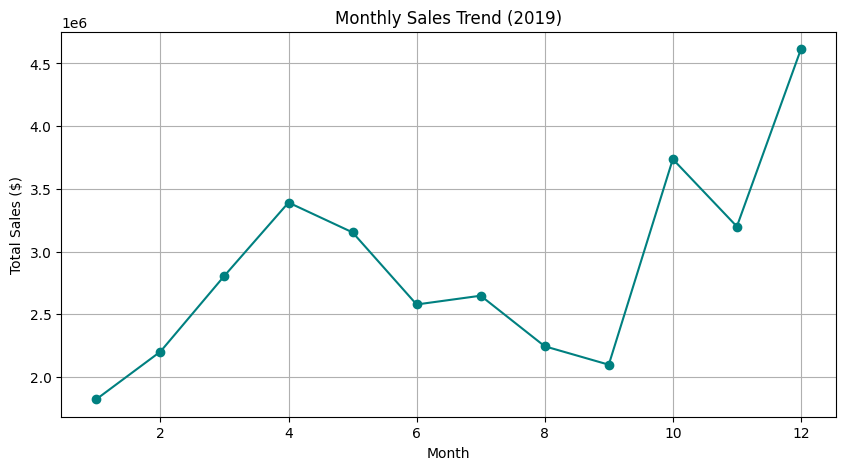

In [14]:
monthly_sales = all_data.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='teal')
plt.title('Monthly Sales Trend (2019)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True)
plt.show()


Step 5 — Question 2: Sales by City

Which cities contribute the most revenue?

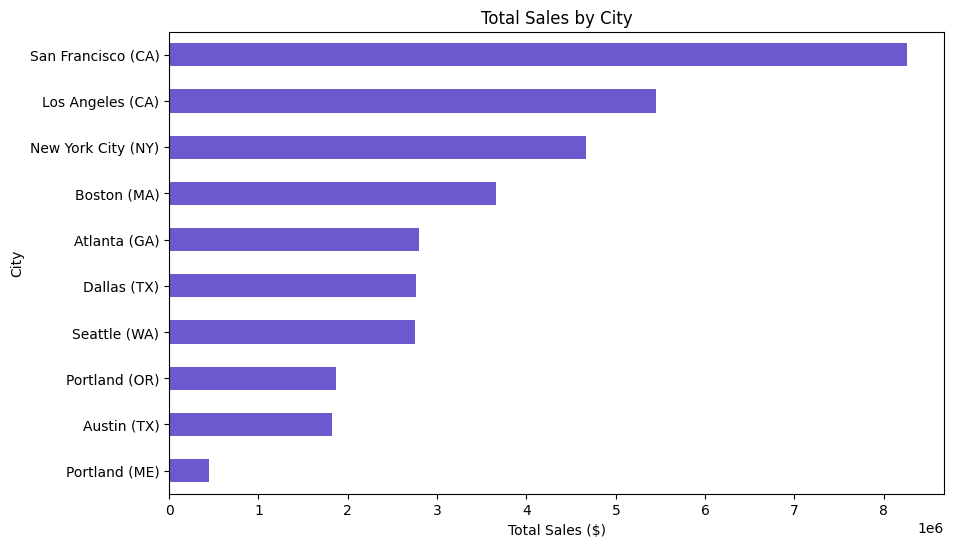

In [15]:
city_sales = all_data.groupby('City')['Sales'].sum().sort_values(ascending=True)

plt.figure(figsize=(10,6))
city_sales.plot(kind='barh', color='slateblue')
plt.title('Total Sales by City')
plt.xlabel('Total Sales ($)')
plt.ylabel('City')
plt.show()


Step 6 — Question 3: Top-Selling Products

Which products generate the most revenue?

/tmp/ipython-input-856379845.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_sales.values, y=product_sales.index, palette='viridis')


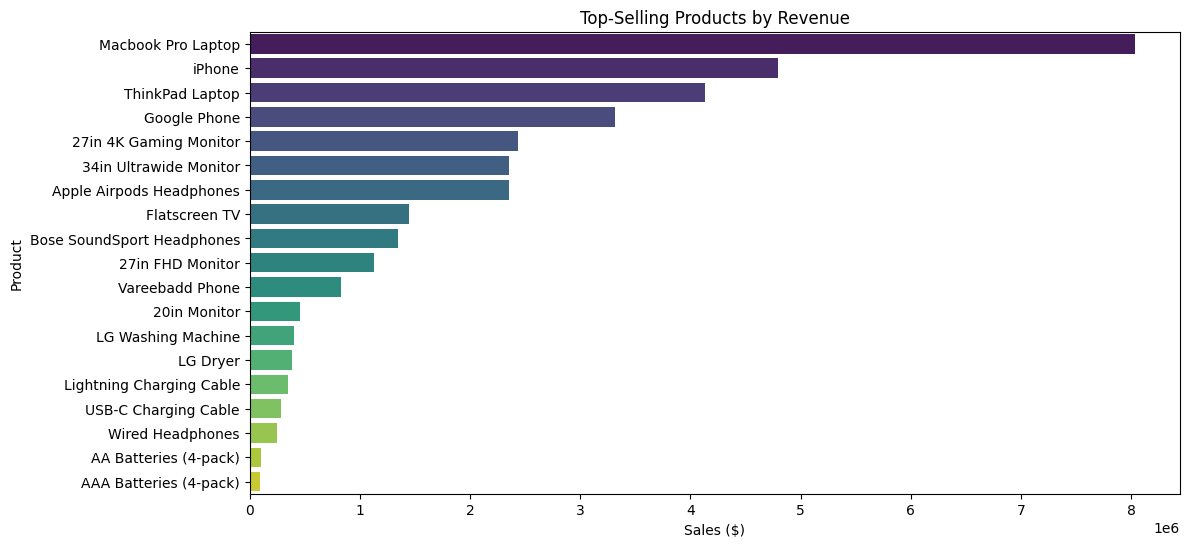

In [16]:
product_sales = all_data.groupby('Product')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=product_sales.values, y=product_sales.index, palette='viridis')
plt.title('Top-Selling Products by Revenue')
plt.xlabel('Sales ($)')
plt.ylabel('Product')
plt.show()


Step 7 — Question 4: Revenue Distribution

How does order revenue vary?

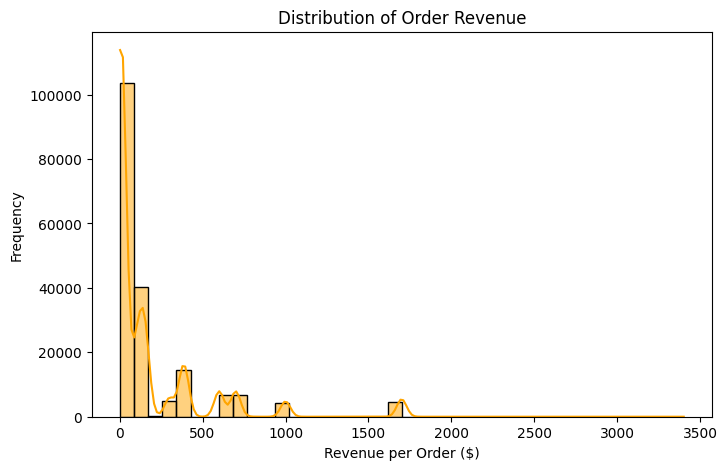

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(all_data['Sales'], bins=40, color='orange', kde=True)
plt.title('Distribution of Order Revenue')
plt.xlabel('Revenue per Order ($)')
plt.ylabel('Frequency')
plt.show()


Step 8 — Question 5: Co-purchased Products

Which products are frequently bought together?

In [18]:
# Filter orders with more than one product
df_dup = all_data[all_data['Order ID'].duplicated(keep=False)]
df_dup['Grouped'] = df_dup.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))
df_dup = df_dup[['Order ID', 'Grouped']].drop_duplicates()

from itertools import combinations
from collections import Counter

count = Counter()
for row in df_dup['Grouped']:
    row_list = row.split(',')
    count.update(Counter(combinations(row_list, 2)))

for key, value in count.most_common(5):
    print(key, value)


('iPhone', 'Lightning Charging Cable') 1005
('Google Phone', 'USB-C Charging Cable') 987
('iPhone', 'Wired Headphones') 447
('Google Phone', 'Wired Headphones') 414
('Vareebadd Phone', 'USB-C Charging Cable') 361


/tmp/ipython-input-586690754.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dup['Grouped'] = df_dup.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))
